# Populate HexMazeThetaV1 for all hex maze sessions

Runs the full LFP to theta pipeline for all sessions that have ephys data and exist in `HexMazeBlock`, then populates `HexMazeThetaV1`.

Pipeline steps (handled automatically by `setup_theta_pipeline`):
1. LFP lowpass filter matched to the session's actual raw sampling rate (fetched from the database)
2. LFP electrode group (all electrodes from sort groups, excluding bad channels)
3. LFP filtered and downsampled to ~1000 Hz (`LFPV1`) — **~2 hours per session**
4. Theta bandpass filter (5–11 Hz) matched to actual LFP output rate
5. Theta-band LFP (`LFPBandV1`)
6. Analytic signal saved to NWB (`HexMazeThetaV1`)

In [1]:
import datajoint as dj
import numpy as np

import spyglass.common as sgc
import spyglass.lfp as lfp
from spyglass.lfp.analysis.v1.lfp_band import LFPBandV1, LFPBandSelection

from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock
# Berke lab IM-* sessions were sorted with spikesorting v1, Frank lab sessions with v0.
# These helpers pick the right table for a session so we don't have to write lab-specific code
from spyglass_hexmaze.spikesorting_helpers import sort_group_table, get_electrode_ids
from spyglass_hexmaze.hex_maze_decoding import HexMazeThetaV1
# The theta band is fixed in the module so every session is filtered identically
from spyglass_hexmaze.hex_maze_theta import THETA_FILTER_NAME

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-08-03 11:53:06,559][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

## Check current state of tables

In [2]:
# The run-epoch interval(s) to process for a session.
# Berke lab IM-* sessions have a single run epoch: "00_r1"
# Frank lab sessions have 4 or 5 run epochs:
# epoch 1: "01_r1", epoch 3: "03_r2", epoch 5: "05_r3", epoch 7: "07_r4", epoch 9: "09_r5"
# In both cases we just look up the run interval of every epoch that has a HexMazeBlock from TaskEpoch
def get_run_intervals(nwb_file_name):
    """Return the run-epoch interval_list_name(s) that contain hex maze blocks."""
    hex_epochs = sorted(set((HexMazeBlock & {"nwb_file_name": nwb_file_name}).fetch("epoch")))
    return [
        (sgc.TaskEpoch & {"nwb_file_name": nwb_file_name, "epoch": e}).fetch1("interval_list_name")
        for e in hex_epochs
    ]


# All sessions in HexMazeBlock that also have ephys data (a SortGroup entry)
all_hex_sessions = sorted(set(HexMazeBlock.fetch("nwb_file_name")))
files = sorted(
    f for f in all_hex_sessions if len(sort_group_table(f) & {"nwb_file_name": f}) > 0
)

# Expand each ephys session into one (session, run interval) job per run epoch.
# This is the unit of work for the whole pipeline below.
jobs = [
    {"nwb_file_name": f, "interval_list_name": iv}
    for f in files
    for iv in get_run_intervals(f)
]

print(f"Found {len(files)} hex maze sessions with ephys, {len(jobs)} epochs:")
for f in files:
    intervals = [j["interval_list_name"] for j in jobs if j["nwb_file_name"] == f]
    print(f"  {f}: {intervals}")

# What's already populated
print(f"\nHexMazeThetaV1 already has {len(HexMazeThetaV1())} entries:")
display(HexMazeThetaV1())

Found 41 hex maze sessions with ephys, 86 epochs:
  BraveLu20240617_.nwb: ['01_r1', '03_r2', '05_r3', '07_r4']
  BraveLu20240622_.nwb: ['01_r1', '03_r2', '05_r3']
  IM-1478_20220719_.nwb: ['00_r1']
  IM-1478_20220720_.nwb: ['00_r1']
  IM-1478_20220724_.nwb: ['00_r1']
  IM-1478_20220725_.nwb: ['00_r1']
  IM-1478_20220726_.nwb: ['00_r1']
  IM-1478_20220727_.nwb: ['00_r1']
  IM-1594_20230725_.nwb: ['00_r1']
  IM-1594_20230726_.nwb: ['00_r1']
  IM-1594_20230727_.nwb: ['00_r1']
  IM-1594_20230728_.nwb: ['00_r1']
  IM-1871_20250731_.nwb: ['00_r1']
  IM-1871_20250801_.nwb: ['00_r1']
  IM-1871_20250802_.nwb: ['00_r1']
  IM-1871_20250803_.nwb: ['00_r1']
  IM-1871_20250804_.nwb: ['00_r1']
  IM-1871_20250805_.nwb: ['00_r1']
  IM-1871_20250806_.nwb: ['00_r1']
  IM-1871_20250807_.nwb: ['00_r1']
  IM-1941_20260207_.nwb: ['00_r1']
  IM-1947_20260401_.nwb: ['00_r1']
  IM-1947_20260402_.nwb: ['00_r1']
  IM-1947_20260403_.nwb: ['00_r1']
  IM-1947_20260404_.nwb: ['00_r1']
  IM-1947_20260405_.nwb: ['00_r1

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform
109fcddb-9d89-8211-dd47-b54d11c9b050,Theta 5-11 Hz,1000,Lily20251221_.nwb,03_r2,1000,Lily20251221_J0J8IVUHFP.nwb,8810aef5-7a93-4d92-8875-9b55d1c428b6
147003e5-a74d-7b86-c089-878364734702,Theta 5-11 Hz,1000,Lily20251221_.nwb,01_r1,1000,Lily20251221_44YMN4MY6Y.nwb,c00a5a1b-20e6-410a-8cfc-00ef22f35c62
168086c2-9629-3866-120b-8ff37b58d07b,Theta 5-11 Hz,1000,IM-1871_20250806_.nwb,00_r1,1000,IM-1871_20250806_J4JQI8T0XV.nwb,c11e29a8-554e-405c-b477-a67bf82b8337
171af025-8fa5-fe7a-ca10-39e441b9878b,Theta 5-11 Hz,1000,Lily20251217_.nwb,09_r5,1000,Lily20251217_H1OSD8S93K.nwb,7ef42580-6763-4942-9eeb-533308849f11
1981a6c7-c84e-d4d7-21e7-f51dde7cb167,Theta 5-11 Hz,1000,Lily20251217_.nwb,05_r3,1000,Lily20251217_ZPJU8BB9HZ.nwb,984c8bc6-5619-42f9-bd4e-4e504a219003
236edb91-f3f0-34bf-eba7-363f9969a6c5,Theta 5-11 Hz,1034,IM-1594_20230725_.nwb,00_r1,1034,IM-1594_20230725_I6PIXZAM0L.nwb,9982813f-a33d-499b-a6ff-c2f83776188c
23be3673-10cf-6c31-a0cb-06c73e0f0235,Theta 5-11 Hz,1000,BraveLu20240617_.nwb,05_r3,1000,BraveLu20240617_R1ZB5VP5WI.nwb,f02801af-b70a-4191-8337-24e2be85e25b
24f20c68-7544-a493-612f-85c875ea3428,Theta 5-11 Hz,1034,IM-1871_20250803_.nwb,00_r1,1034,IM-1871_20250803_CAD8K4VESP.nwb,d9ad5cd4-57f4-4640-a454-70218ca7add7
28391cfb-3268-d0a9-32bb-7d77d1c6f2f1,Theta 5-11 Hz,1000,Toby20250316_.nwb,01_r1,1000,Toby20250316_IHTGHYMA5D.nwb,f6986815-3e16-4e43-8a92-fef16622e561
2c09f8f8-bac9-9db2-787e-10f412ee61e7,Theta 5-11 Hz,1000,IM-1871_20250731_.nwb,00_r1,1000,IM-1871_20250731_L6L5F45XOF.nwb,f3e37a48-aef7-475c-87d5-2513f95240c5


## Helper to get electrode IDs for a session

Uses all electrodes from sort groups

In [3]:
# Confirm get_electrode_ids works on a known session
test_file = sorted(files)[0]
test_electrodes = get_electrode_ids(test_file)
print(f"{test_file}: {len(test_electrodes)} electrodes")
print(test_electrodes)

BraveLu20240617_.nwb: 128 electrodes
[0, 1, 2, 3, 4, 5, 6, 7, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8, 9, 10, 11, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 12, 13, 14, 15, 120, 121, 122, 123, 124, 125, 126, 127, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


## Pipeline setup — loop through all sessions

Calls `setup_theta_pipeline` for each session not yet in `LFPBandSelection`.
The `LFPV1` populate inside takes ~2 hours per session. The loop is safe to interrupt
and restart — all inserts use `skip_duplicates`, and the recovery cell below reloads
any keys already in the database.

In [4]:
# Keyed by (nwb_file_name, interval_list_name) since a session can have several run epochs
lfp_band_keys = {}

# In LFPBandSelection the run interval is stored as target_interval_list_name
job_restrictions = [
    {"nwb_file_name": j["nwb_file_name"], "target_interval_list_name": j["interval_list_name"]}
    for j in jobs
]

# Recover any LFPBandSelection keys already in the DB (safe after kernel restart)
for row in (
    LFPBandSelection & job_restrictions & {"filter_name": THETA_FILTER_NAME}
).fetch("KEY", as_dict=True):
    key = (row["nwb_file_name"], row["target_interval_list_name"])
    lfp_band_keys[key] = row

print(f"Recovered {len(lfp_band_keys)} LFP band key(s) already in DB:")
for nwb, interval in sorted(lfp_band_keys):
    print(f"  {nwb}  [{interval}]")

Recovered 86 LFP band key(s) already in DB:
  BraveLu20240617_.nwb  [01_r1]
  BraveLu20240617_.nwb  [03_r2]
  BraveLu20240617_.nwb  [05_r3]
  BraveLu20240617_.nwb  [07_r4]
  BraveLu20240622_.nwb  [01_r1]
  BraveLu20240622_.nwb  [03_r2]
  BraveLu20240622_.nwb  [05_r3]
  IM-1478_20220719_.nwb  [00_r1]
  IM-1478_20220720_.nwb  [00_r1]
  IM-1478_20220724_.nwb  [00_r1]
  IM-1478_20220725_.nwb  [00_r1]
  IM-1478_20220726_.nwb  [00_r1]
  IM-1478_20220727_.nwb  [00_r1]
  IM-1594_20230725_.nwb  [00_r1]
  IM-1594_20230726_.nwb  [00_r1]
  IM-1594_20230727_.nwb  [00_r1]
  IM-1594_20230728_.nwb  [00_r1]
  IM-1871_20250731_.nwb  [00_r1]
  IM-1871_20250801_.nwb  [00_r1]
  IM-1871_20250802_.nwb  [00_r1]
  IM-1871_20250803_.nwb  [00_r1]
  IM-1871_20250804_.nwb  [00_r1]
  IM-1871_20250805_.nwb  [00_r1]
  IM-1871_20250806_.nwb  [00_r1]
  IM-1871_20250807_.nwb  [00_r1]
  IM-1941_20260207_.nwb  [00_r1]
  IM-1947_20260401_.nwb  [00_r1]
  IM-1947_20260402_.nwb  [00_r1]
  IM-1947_20260403_.nwb  [00_r1]
  IM-1

### Run setup_theta_pipeline for each session not yet in LFPBandSelection

In [5]:
todo = [
    j for j in jobs
    if (j["nwb_file_name"], j["interval_list_name"]) not in lfp_band_keys
]
print(f"{len(lfp_band_keys)} job(s) already have LFPBandSelection keys.")
print(f"{len(todo)} job(s) still need setup_theta_pipeline:")
for j in todo:
    print(f"  {j['nwb_file_name']}  [{j['interval_list_name']}]")

for j in todo:
    nwb_file_name = j["nwb_file_name"]
    interval_list_name = j["interval_list_name"]
    # One LFP electrode group per file (same electrodes for all of its run epochs);
    # setup_theta_pipeline skips duplicates, so reusing the name across intervals is fine.
    lfp_group_name = nwb_file_name.replace("_.nwb", "_lfp")
    electrode_ids = get_electrode_ids(nwb_file_name)
    print(f"\nSetting up {nwb_file_name} [{interval_list_name}] ({len(electrode_ids)} electrodes)...")
    lfp_band_keys[(nwb_file_name, interval_list_name)] = HexMazeThetaV1.setup_theta_pipeline(
        nwb_file_name=nwb_file_name,
        lfp_electrode_group_name=lfp_group_name,
        electrode_ids=electrode_ids,
        interval_list_name=interval_list_name,
    )
    print(f"  Done. Key: {lfp_band_keys[(nwb_file_name, interval_list_name)]}")

print(f"\n{len(lfp_band_keys)} job(s) ready for LFPBandV1 populate.")

86 job(s) already have LFPBandSelection keys.
0 job(s) still need setup_theta_pipeline:

86 job(s) ready for LFPBandV1 populate.


## Populate LFPBandV1 and HexMazeThetaV1

Once all setup cells above have finished, populate the theta-band LFP and then the final table.
These are much faster than `LFPV1` — a few minutes each.

In [6]:
# Populate LFPBandV1 for all jobs whose setup is complete
# (safe to re-run — already-populated entries are skipped)
for (nwb_file, interval), lfp_band_key in sorted(lfp_band_keys.items()):
    print(f"Populating LFPBandV1 for {nwb_file} [{interval}]...")
    LFPBandV1().populate(lfp_band_key)
    print(f"  done.")

display(LFPBandV1() & [{"nwb_file_name": f} for f in files])

Populating LFPBandV1 for BraveLu20240617_.nwb [01_r1]...
  done.
Populating LFPBandV1 for BraveLu20240617_.nwb [03_r2]...
  done.
Populating LFPBandV1 for BraveLu20240617_.nwb [05_r3]...
  done.
Populating LFPBandV1 for BraveLu20240617_.nwb [07_r4]...
  done.
Populating LFPBandV1 for BraveLu20240622_.nwb [01_r1]...
  done.
Populating LFPBandV1 for BraveLu20240622_.nwb [03_r2]...
  done.
Populating LFPBandV1 for BraveLu20240622_.nwb [05_r3]...
  done.
Populating LFPBandV1 for IM-1478_20220719_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1478_20220720_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1478_20220724_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1478_20220725_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1478_20220726_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1478_20220727_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1594_20230725_.nwb [00_r1]...
  done.
Populating LFPBandV1 for IM-1594_20230726_.nwb [00_r1]...
  done.
Populating LFPBan

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_band_object_id the NWB object ID for loading this object from the file
0416029d-afde-7967-6820-fdd6f81f3f50,Ripple 150-250 Hz,1034,IM-1871_20250803_.nwb,00_r1,1034,IM-1871_20250803_DVFZB1UDH9.nwb,00_r1 lfp band 1034Hz,e8a8869d-1b3a-4a91-9053-5178354fd6f1
109fcddb-9d89-8211-dd47-b54d11c9b050,Theta 5-11 Hz,1000,Lily20251221_.nwb,03_r2,1000,Lily20251221_PC5YFWTFPQ.nwb,03_r2 lfp band 1000Hz,d11f271a-49e0-414b-a005-7636cf24b085
147003e5-a74d-7b86-c089-878364734702,Theta 5-11 Hz,1000,Lily20251221_.nwb,01_r1,1000,Lily20251221_JNHRFT52OP.nwb,01_r1 lfp band 1000Hz,d91026f0-6893-420a-bfb6-261c1581da76
14892619-7346-a8b1-30ea-63465f4876cf,Ripple 150-250 Hz,1034,IM-1871_20250804_.nwb,00_r1,1034,IM-1871_20250804_DWMMQ0B4WV.nwb,00_r1 lfp band 1034Hz,2a91a2da-e477-4c41-895d-a0efed53a2db
15f98b82-6683-657e-6e4c-589b020c2632,Theta 5-11 Hz,1000,Toby20250318_.nwb,07_r4_noPreTrialTimes,100,Toby20250318_H7UD8XONMP.nwb,07_r4_noPreTrialTimes lfp band 100Hz,d40788e1-3f19-486e-89b6-9504fd598f1b
168086c2-9629-3866-120b-8ff37b58d07b,Theta 5-11 Hz,1000,IM-1871_20250806_.nwb,00_r1,1000,IM-1871_20250806_6I9KMJN9YO.nwb,00_r1 lfp band 1000Hz,00434128-e79b-41c0-a604-387aa0fddb39
171af025-8fa5-fe7a-ca10-39e441b9878b,Theta 5-11 Hz,1000,Lily20251217_.nwb,09_r5,1000,Lily20251217_MC0FHPDQLU.nwb,09_r5 lfp band 1000Hz,4eb4cfea-379c-4da3-87ea-41092a47fc22
1981a6c7-c84e-d4d7-21e7-f51dde7cb167,Theta 5-11 Hz,1000,Lily20251217_.nwb,05_r3,1000,Lily20251217_9E8IKS6RYI.nwb,05_r3 lfp band 1000Hz,43533d5b-54d3-48c7-8cff-a8a69ef34c21
1d2d7af5-8758-4103-e367-9985abc3a67e,Ripple 150-250 Hz,1034,IM-1871_20250805_.nwb,00_r1,1034,IM-1871_20250805_1AFEHECI83.nwb,00_r1 lfp band 1034Hz,0ad2471a-e559-4cfb-90bb-e100f789f7cd
1f5ef082-1668-e949-0455-43d28f4d1ff6,Theta 5-11 Hz,1000,Toby20250316_.nwb,05_r3_noPreTrialTimes,100,Toby20250316_7CGEIWD7N6.nwb,05_r3_noPreTrialTimes lfp band 100Hz,aed6c54c-c89b-4082-be18-dc11c94bbff4


In [7]:
# Populate HexMazeThetaV1 for all jobs
# (computes analytic signal, phase, power and saves to analysis NWB)
for (nwb_file, interval), lfp_band_key in sorted(lfp_band_keys.items()):
    print(f"Populating HexMazeThetaV1 for {nwb_file} [{interval}]...")
    HexMazeThetaV1().populate(lfp_band_key)
    print(f"  done.")

display(HexMazeThetaV1() & [{"nwb_file_name": f} for f in files])

Populating HexMazeThetaV1 for BraveLu20240617_.nwb [01_r1]...
  done.
Populating HexMazeThetaV1 for BraveLu20240617_.nwb [03_r2]...
  done.
Populating HexMazeThetaV1 for BraveLu20240617_.nwb [05_r3]...
  done.
Populating HexMazeThetaV1 for BraveLu20240617_.nwb [07_r4]...
  done.
Populating HexMazeThetaV1 for BraveLu20240622_.nwb [01_r1]...
  done.
Populating HexMazeThetaV1 for BraveLu20240622_.nwb [03_r2]...
  done.
Populating HexMazeThetaV1 for BraveLu20240622_.nwb [05_r3]...
  done.
Populating HexMazeThetaV1 for IM-1478_20220719_.nwb [00_r1]...
  done.
Populating HexMazeThetaV1 for IM-1478_20220720_.nwb [00_r1]...
  done.
Populating HexMazeThetaV1 for IM-1478_20220724_.nwb [00_r1]...
  done.
Populating HexMazeThetaV1 for IM-1478_20220725_.nwb [00_r1]...
  done.
Populating HexMazeThetaV1 for IM-1478_20220726_.nwb [00_r1]...
  done.
Populating HexMazeThetaV1 for IM-1478_20220727_.nwb [00_r1]...
  done.
Populating HexMazeThetaV1 for IM-1594_20230725_.nwb [00_r1]...
  done.
Populating He

[2026-08-03 11:53:32,601][WARNING]: Skipped checksum for file with hash: 1fa0d804-26c7-ad64-a5fd-54b9fde70396, and path: /stelmo/nwb/analysis/Toby20250318/Toby20250318_1I4H3O11WT.nwb
[2026-08-03 11:53:32,612][WARNING]: Skipped checksum for file with hash: 1fa0d804-26c7-ad64-a5fd-54b9fde70396, and path: /stelmo/nwb/analysis/Toby20250318/Toby20250318_1I4H3O11WT.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if p

  done.
Populating HexMazeThetaV1 for Toby20250318_.nwb [07_r4]...


[2026-08-03 12:36:52,680][WARNING]: Skipped checksum for file with hash: 52c4549c-64d3-10b5-32d2-676a0b67371e, and path: /stelmo/nwb/analysis/Toby20250318/Toby20250318_KOOLBFMVOI.nwb
[2026-08-03 12:36:52,686][WARNING]: Skipped checksum for file with hash: 52c4549c-64d3-10b5-32d2-676a0b67371e, and path: /stelmo/nwb/analysis/Toby20250318/Toby20250318_KOOLBFMVOI.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if p

  done.
Populating HexMazeThetaV1 for Toby20250319_.nwb [01_r1]...


...

[2026-08-03 16:42:53,586][WARNING]: Skipped checksum for file with hash: ea1007d1-9fd0-1f27-d1a6-441b9b033cdf, and path: /stelmo/nwb/analysis/Toby20250327/Toby20250327_W0PCPKAKA1.nwb
[2026-08-03 16:42:53,601][WARNING]: Skipped checksum for file with hash: ea1007d1-9fd0-1f27-d1a6-441b9b033cdf, and path: /stelmo/nwb/analysis/Toby20250327/Toby20250327_W0PCPKAKA1.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if p

  done.
Populating HexMazeThetaV1 for Toby20250327_.nwb [07_r4]...


[2026-08-03 17:05:51,051][WARNING]: Skipped checksum for file with hash: 3d7bdd74-f09a-ea64-a3b0-26d10ec30ee7, and path: /stelmo/nwb/analysis/Toby20250327/Toby20250327_Q09878H1FK.nwb
[2026-08-03 17:05:51,056][WARNING]: Skipped checksum for file with hash: 3d7bdd74-f09a-ea64-a3b0-26d10ec30ee7, and path: /stelmo/nwb/analysis/Toby20250327/Toby20250327_Q09878H1FK.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if p

  done.


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform
109fcddb-9d89-8211-dd47-b54d11c9b050,Theta 5-11 Hz,1000,Lily20251221_.nwb,03_r2,1000,Lily20251221_J0J8IVUHFP.nwb,8810aef5-7a93-4d92-8875-9b55d1c428b6
147003e5-a74d-7b86-c089-878364734702,Theta 5-11 Hz,1000,Lily20251221_.nwb,01_r1,1000,Lily20251221_44YMN4MY6Y.nwb,c00a5a1b-20e6-410a-8cfc-00ef22f35c62
168086c2-9629-3866-120b-8ff37b58d07b,Theta 5-11 Hz,1000,IM-1871_20250806_.nwb,00_r1,1000,IM-1871_20250806_J4JQI8T0XV.nwb,c11e29a8-554e-405c-b477-a67bf82b8337
171af025-8fa5-fe7a-ca10-39e441b9878b,Theta 5-11 Hz,1000,Lily20251217_.nwb,09_r5,1000,Lily20251217_H1OSD8S93K.nwb,7ef42580-6763-4942-9eeb-533308849f11
1981a6c7-c84e-d4d7-21e7-f51dde7cb167,Theta 5-11 Hz,1000,Lily20251217_.nwb,05_r3,1000,Lily20251217_ZPJU8BB9HZ.nwb,984c8bc6-5619-42f9-bd4e-4e504a219003
236edb91-f3f0-34bf-eba7-363f9969a6c5,Theta 5-11 Hz,1034,IM-1594_20230725_.nwb,00_r1,1034,IM-1594_20230725_I6PIXZAM0L.nwb,9982813f-a33d-499b-a6ff-c2f83776188c
23be3673-10cf-6c31-a0cb-06c73e0f0235,Theta 5-11 Hz,1000,BraveLu20240617_.nwb,05_r3,1000,BraveLu20240617_R1ZB5VP5WI.nwb,f02801af-b70a-4191-8337-24e2be85e25b
24f20c68-7544-a493-612f-85c875ea3428,Theta 5-11 Hz,1034,IM-1871_20250803_.nwb,00_r1,1034,IM-1871_20250803_CAD8K4VESP.nwb,d9ad5cd4-57f4-4640-a454-70218ca7add7
28391cfb-3268-d0a9-32bb-7d77d1c6f2f1,Theta 5-11 Hz,1000,Toby20250316_.nwb,01_r1,1000,Toby20250316_IHTGHYMA5D.nwb,f6986815-3e16-4e43-8a92-fef16622e561
2c09f8f8-bac9-9db2-787e-10f412ee61e7,Theta 5-11 Hz,1000,IM-1871_20250731_.nwb,00_r1,1000,IM-1871_20250731_L6L5F45XOF.nwb,f3e37a48-aef7-475c-87d5-2513f95240c5


## Sanity check — fetch and plot for one session

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,analytic_signal_object_id real+imag parts of Hilbert transform
ffdc1372-d44c-8381-1fb9-e81595e2a911,Theta 5-11 Hz,1000,IM-1478_20220725_.nwb,00_r1,1000,IM-1478_20220725_WFROR1P4MT.nwb,c1ec6f57-82aa-4fdd-b3cd-8f7caa129bab


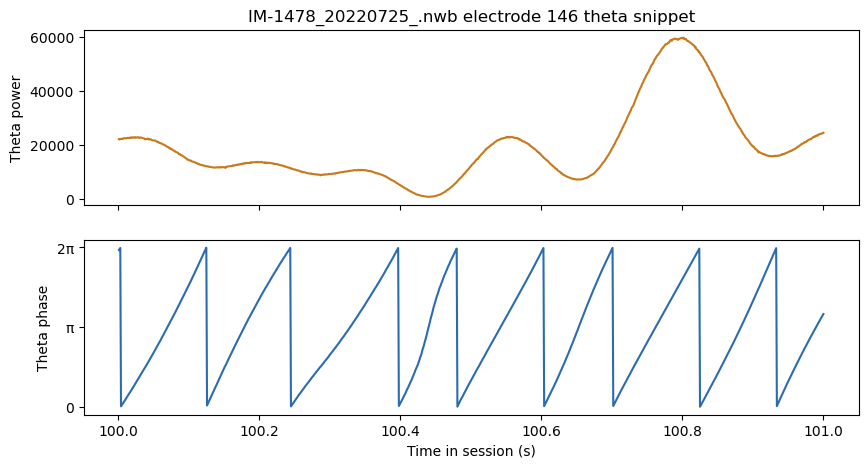

In [8]:
import matplotlib.pyplot as plt

# Pick a session and interval
check_nwb = "IM-1478_20220725_.nwb"
check_interval_list_name = "00_r1"

theta_entry = HexMazeThetaV1() & {"nwb_file_name": check_nwb, "target_iterval_list_name": check_interval_list_name}
display(theta_entry)

# Choose an example electrode so we don't load the whole thing
REFERENCE_ELECTRODE = 146
phase_df = theta_entry.fetch_theta_phase([REFERENCE_ELECTRODE])
power_df = theta_entry.fetch_theta_power([REFERENCE_ELECTRODE])

phase = phase_df[f"electrode {REFERENCE_ELECTRODE}"]   # radians [0, 2π], time-indexed
power = power_df[f"electrode {REFERENCE_ELECTRODE}"]

t0, t1 = 100, 101  # seconds

fig, (ax_power, ax_phase) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax_power.plot(power.loc[t0:t1], color="#c8791a", lw=1.5)
ax_phase.plot(phase.loc[t0:t1], color="#2b6cb0", lw=1.5)
ax_power.set_title(f"{check_nwb} electrode {REFERENCE_ELECTRODE} theta snippet")
ax_power.set_ylabel("Theta power")
ax_phase.set_ylabel("Theta phase")
ax_phase.set_xlabel("Time in session (s)")
ax_phase.set_yticks([0, np.pi, 2 * np.pi])
ax_phase.set_yticklabels(["0", "π", "2π"])
plt.show()
